
## Proje Amacı ve Tanımı
**Coreference Resolution (Zamir/Varlık Çözümleme):** Bir metin içerisinde geçen farklı zamir veya varlık ifadelerinin (mentions), aslında metin içerisinde aynı gerçek varlığa (entity) atıfta bulunduğunu tespit etme sürecidir. Bu süreçte, metindeki zamirler (örn: *o, ona, kendisi*) ve isim öbekleri (örn: *Mirko Czentovic, genç satranç şampiyonu*), aynı varlık kimliği (Entity ID) altında gruplandırılır.

Bu projede, bu görevi bir **Ardışık Sınıflandırma (Sequence Labeling)** görevi olarak ele alacağız. Verilerimiz CoNLL formatında olup, her bir kelimeye ait bir IOB2 (Inside-Outside-Beginning) etiketi bulunmaktadır (Örn: `B-ENTITY_2`, `I-ENTITY_2`, `0`).

## Kullanılan İstatist
iksel Makine Öğrenmesi Modelleri
Proje kapsamında aşağıdaki 3 farklı istatistiksel makine öğrenmesi modeli eğitilmiş, teorik altyapıları kurulmuş ve performansları karşılaştırılmıştır:

### 1. Multinomial Naive Bayes
Bayes Teoremi'ne dayanan ve özniteliklerin bağımsız olduğunu kabul eden olasılıksal bir modeldir. Metin sınıflandırma ve dizi işaretleme işlemlerinde temel başvuru (baseline) modelidir.
$$
P(C_k \mid \mathbf{x}) = \frac{P(C_k) \cdot P(\mathbf{x} \mid C_k)}{P(\mathbf{x})}
$$

### 2. Çok Terimli Lojistik Regresyon (Softmax Regression)
Özellik ağırlıklarının doğrusal bileşimini olasılık değerine dönüştüren log-lineer bir modeldir. Özellikle çok sınıflı sınıflandırma görevlerinde Softmax fonksiyonu kullanır:
$$
P(y = c \mid \mathbf{x}) = \frac{e^{\mathbf{w}_c^T \mathbf{x}}}{\sum_{j=1}^{K} e^{\mathbf{w}_j^T \mathbf{x}}}
$$

### 3. Çok Katmanlı Algılayıcı (Multilayer Perceptron - MLP)
Girdi katmanı, bir veya daha fazla gizli katman ve çıktı katmanından oluşan yapay sinir ağı mimarisidir. Doğrusal olmayan ilişkileri karmaşık ağırlık güncellemeleri (Geri Yayılım - Backpropagation) ile öğrenir:
$$
a_j^{(l)} = \sigma\left(\sum_{k} w_{jk}^{(l)} a_k^{(l-1)} + b_j^{(l)}\right)
$$

## Adımlar
1. Veri kümesinin yüklenmesi ve CoNLL formatının çözümlenmesi (Sekme/Boşluk uyumlu parser).
2. Türkçe metinler için kelime/token düzeyinde özellik mühendisliği (Feature Engineering).
3. Verinin eğitim (%80) ve test (%20) kümesine bölünmesi ve ardından matris uyumu için düzleştirilmesi (flatten).
4. Naive Bayes, Lojistik Regresyon ve MLP modellerinin eğitilmesi.
5. Sınıf bazında başarı oranlarının (Precision, Recall, F-measure, Accuracy) baskın olan "0" sınıfı elenerek hesaplanması.
6. Lojistik Regresyon modelinin katsayıları incelenerek **Öznitelik Önem Derecesi (Feature Importance)** analizi.
7. Karışıklık Matrisinin (Confusion Matrix) grafik olarak çizilmesi ve karşılaştırılması.

In [12]:
import os

def load_conll(file_path):
    """
    CoNLL dosyasını okur ve cümle yapılarına göre ayrıştırılmış bir liste döndürür.
    Hem tab hem de boşluk ayırıcılarını esnek şekilde destekler.
    """
    sentences = []
    current_sentence = []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            stripped = line.strip('\r\n')
            if not stripped.strip():
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
            else:
                # Öncelikle tab karakterine göre bölmeyi dene
                parts = stripped.split('\t')
                if len(parts) != 2:
                    # Tab yoksa sağdan ilk boşluğa göre böl (kelime ve etiket ayrımı)
                    parts = stripped.rsplit(None, 1)
                
                if len(parts) == 2:
                    current_sentence.append((parts[0].strip(), parts[1].strip()))
                    
        if current_sentence:
            sentences.append(current_sentence)
            
    return sentences

# Veri dosyasını yükleyelim
file_path = "veri.conll"
sentences = load_conll(file_path)
print(f"Toplam yüklenen cümle sayısı: {len(sentences)}")
print(f"Örnek cümle ilk 5 kelime: {sentences[0][:5]}")

Toplam yüklenen cümle sayısı: 563
Örnek cümle ilk 5 kelime: [('Gece', '0'), ('yarısı', '0'), ('New', '0'), ("York'tan", '0'), ('Buenos', '0')]



Varlık çözümleme görevi için her kelimenin morfolojik ve bağlamsal özelliklerini çıkarmamız gerekir. Türkçe sondan eklemeli bir dil olduğundan, kelimenin son ekleri (son 2 ve 3 harfi) ve kelimenin zamir olup olmaması oldukça önemlidir.

Çıkarılan özellikler:
*   Kelimenin kendisi ve küçük harf hali
*   Kelimelerin karakter uzunluğu
*   Tamamen büyük harf olup olmaması (örn: kısaltmalar)
*   Baş harfinin büyük olup olmaması (örn: özel isimler)
*   Rakam olup olmaması
*   **Zamir Kontrolü:** Türkçe şahıs ve işaret zamirleri listesi ile kelime karşılaştırması
*   Kelime önekleri ve sonekleri (Prefix & Suffix)
*   **Bağlamsal Özellikler:** Bir önceki kelime, bir sonraki kelime ve bunların özellikleri (Pencere genişliği = 1).

In [13]:
# Türkçe şahıs, işaret ve dönüşlülük zamirleri
PRONOUNS = {
    "ben", "sen", "o", "biz", "siz", "onlar", 
    "bana", "sana", "ona", "bize", "size", "onlara", 
    "beni", "seni", "onu", "bizi", "sizi", "onları", 
    "bende", "sende", "onda", "bizde", "sizde", "onlarda", 
    "benden", "senden", "ondan", "bizden", "sizden", "onlardan", 
    "benim", "senin", "onun", "bizim", "sizin", "onların", 
    "kendisi", "kendileri", "kendi", "kendime", "kendine", "kendini", 
    "kendinde", "kendinden", "kendim", "kendimiz", "bu", "şu", "bunlar", "şunlar"
}

def word2features(sent, i):
    """
    Cümledeki i. kelime için nitelikleri (features) çıkarır.
    """
    word = sent[i][0]
    
    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word.len()': len(word),
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
        'word.is_pronoun': word.lower() in PRONOUNS,
        'word.suffix3': word[-3:].lower() if len(word) >= 3 else word.lower(),
        'word.suffix2': word[-2:].lower() if len(word) >= 2 else word.lower(),
        'word.prefix3': word[:3].lower() if len(word) >= 3 else word.lower(),
        'word.prefix2': word[:2].lower() if len(word) >= 2 else word.lower(),
    }
    
    # Bir önceki kelime özellikleri (Bağlam -1)
    if i > 0:
        word1 = sent[i-1][0]
        features.update({
            '-1:word.lower()': word1.lower(),
            '-1:word.istitle()': word1.istitle(),
            '-1:word.is_pronoun': word1.lower() in PRONOUNS,
        })
    else:
        features['BOS'] = True # Cümle başlangıcı

    # Bir sonraki kelime özellikleri (Bağlam +1)
    if i < len(sent) - 1:
        word1 = sent[i+1][0]
        features.update({
            '+1:word.lower()': word1.lower(),
            '+1:word.istitle()': word1.istitle(),
            '+1:word.is_pronoun': word1.lower() in PRONOUNS,
        })
    else:
        features['EOS'] = True # Cümle bitişi
        
    return features

In [14]:
def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]

def sent2labels(sent):
    return [label for token, label in sent]

In [15]:
import numpy as np
from sklearn.feature_extraction import DictVectorizer
import torch
from transformers import AutoTokenizer, AutoModel
from scipy.sparse import hstack

# Cümle bazlı karıştırma
np.random.seed(42)
indices = np.arange(len(sentences))
np.random.shuffle(indices)

split_idx = int(0.8 * len(sentences))
train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

X_train_sentences = [sent2features(sentences[idx]) for idx in train_indices]
y_train_sentences = [sent2labels(sentences[idx]) for idx in train_indices]

X_test_sentences = [sent2features(sentences[idx]) for idx in test_indices]
y_test_sentences = [sent2labels(sentences[idx]) for idx in test_indices]

# --- DÜZLEŞTİRME (FLATTEN) ADIMI ---
# Confusion Matrix ve Classifier kütüphanelerinin uyumu için listeleri tek boyutlu dizi haline getiriyoruz
X_train_raw = [token for sent in X_train_sentences for token in sent]
y_train = [label for sent in y_train_sentences for label in sent]

X_test_raw = [token for sent in X_test_sentences for token in sent]
y_test = [label for sent in y_test_sentences for label in sent]

print(f"Eğitim Kümesi Token Sayısı: {len(X_train_raw)}")
print(f"Test Kümesi Token Sayısı: {len(X_test_raw)}")

# Özellik vektörleştirme
vectorizer = DictVectorizer(sparse=True)
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

print(f"Vektörleştirilmiş özellik uzayı boyutu: {X_train.shape[1]}")

# --- BERTurk ÖZNİTELİK EKLEME ADIMI ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"BERT modeli için cihaz: {device}")
tokenizer = AutoTokenizer.from_pretrained("dbmdz/bert-base-turkish-cased")
bert_model = AutoModel.from_pretrained("dbmdz/bert-base-turkish-cased").to(device)

def extract_bert_embeddings(sentences_list, tokenizer, model, device):
    all_embeddings = []
    # Her cümle için
    for sentence in sentences_list:
        words = [token for token, label in sentence]
        if not words:
            continue
        
        # BERT Tokenizer wordpiece hizalaması için is_split_into_words=True kullanıyoruz
        inputs = tokenizer(words, is_split_into_words=True, return_tensors="pt", add_special_tokens=True).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            
        last_hidden = outputs.last_hidden_state[0] # (num_tokens, 768)
        word_ids = inputs.word_ids(batch_index=0)
        
        # Alt-kelime indekslerini kelime kimliklerine göre grupla
        word_to_tokens = {}
        for token_idx, word_id in enumerate(word_ids):
            if word_id is not None:
                if word_id not in word_to_tokens:
                    word_to_tokens[word_id] = []
                word_to_tokens[word_id].append(token_idx)
                
        # Kelime vektörlerini oluştur
        for word_id in range(len(words)):
            token_indices = word_to_tokens.get(word_id, [])
            if token_indices:
                # Alt-kelimelerin ortalamasını al
                word_emb = last_hidden[token_indices].mean(dim=0).cpu().numpy()
            else:
                word_emb = np.zeros(768)
            all_embeddings.append(word_emb)
            
    return np.array(all_embeddings)

# Cümle bazlı listelerimiz
train_sentences_list = [sentences[idx] for idx in train_indices]
test_sentences_list = [sentences[idx] for idx in test_indices]

print("Eğitim kümesi için BERT vektörleri çıkarılıyor...")
X_train_bert = extract_bert_embeddings(train_sentences_list, tokenizer, bert_model, device)

print("Test kümesi için BERT vektörleri çıkarılıyor...")
X_test_bert = extract_bert_embeddings(test_sentences_list, tokenizer, bert_model, device)

# Biçimsel ve anlamsal özniteliklerin scipy hstack ile birleştirilmesi
X_train_combined = hstack([X_train, X_train_bert])
X_test_combined = hstack([X_test, X_test_bert])

print(f"Birleşik özellik uzayı boyutu: {X_train_combined.shape[1]}")


Eğitim Kümesi Token Sayısı: 10956
Test Kümesi Token Sayısı: 2505
Vektörleştirilmiş özellik uzayı boyutu: 15026
BERT modeli için cihaz: cuda
Eğitim kümesi için BERT vektörleri çıkarılıyor...
Test kümesi için BERT vektörleri çıkarılıyor...
Birleşik özellik uzayı boyutu: 15794


In [16]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

print("1. Multinomial Naive Bayes modeli eğitiliyor...")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
print("Naive Bayes eğitildi.")

print("\n2. Logistic Regression modeli eğitiliyor...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_combined, y_train)
print("Logistic Regression eğitildi.")

print("\n3. MLP (Yapay Sinir Ağı) modeli eğitiliyor (bu işlem biraz zaman alabilir)...")
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp_model.fit(X_train_combined, y_train)
print("MLP Classifier eğitildi.")


1. Multinomial Naive Bayes modeli eğitiliyor...
Naive Bayes eğitildi.

2. Logistic Regression modeli eğitiliyor...
Logistic Regression eğitildi.

3. MLP (Yapay Sinir Ağı) modeli eğitiliyor (bu işlem biraz zaman alabilir)...
MLP Classifier eğitildi.


In [17]:
from sklearn.metrics import classification_report

y_pred_nb = nb_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test_combined)
y_pred_mlp = mlp_model.predict(X_test_combined)

# Değerlendirme raporunda gösterilecek sınıflar (0 sınıfı hariç tutulmuştur)
all_classes = sorted(list(set(y_test)))
entity_classes = [c for c in all_classes if c != '0']

print("================= MULTINOMIAL NAIVE BAYES BAŞARI RAPORU =================")
print(classification_report(y_test, y_pred_nb, labels=entity_classes, zero_division=0))

print("\n================= LOJİSTİK REGRESYON BAŞARI RAPORU =================")
print(classification_report(y_test, y_pred_lr, labels=entity_classes, zero_division=0))

print("\n================= YAPAY SİNİR AĞI (MLP) BAŞARI RAPORU =================")
print(classification_report(y_test, y_pred_mlp, labels=entity_classes, zero_division=0))


================= MULTINOMIAL NAIVE BAYES BAŞARI RAPORU =================
              precision    recall  f1-score   support

  B-ENTITY_1       0.00      0.00      0.00        33
 B-ENTITY_11       0.00      0.00      0.00         2
 B-ENTITY_12       0.00      0.00      0.00         3
 B-ENTITY_15       0.00      0.00      0.00        25
 B-ENTITY_16       0.73      0.45      0.56       120
 B-ENTITY_18       0.00      0.00      0.00         3
 B-ENTITY_19       0.00      0.00      0.00         7
  B-ENTITY_2       1.00      0.10      0.18        60
 B-ENTITY_20       0.00      0.00      0.00         2
 B-ENTITY_21       0.00      0.00      0.00        14
 B-ENTITY_22       0.00      0.00      0.00         2
 B-ENTITY_26       0.00      0.00      0.00         1
 B-ENTITY_27       0.00      0.00      0.00         2
  B-ENTITY_5       0.00      0.00      0.00        10
  B-ENTITY_8       0.00      0.00      0.00         7
  B-ENTITY_9       0.00      0.00      0.00         3
  I-ENT

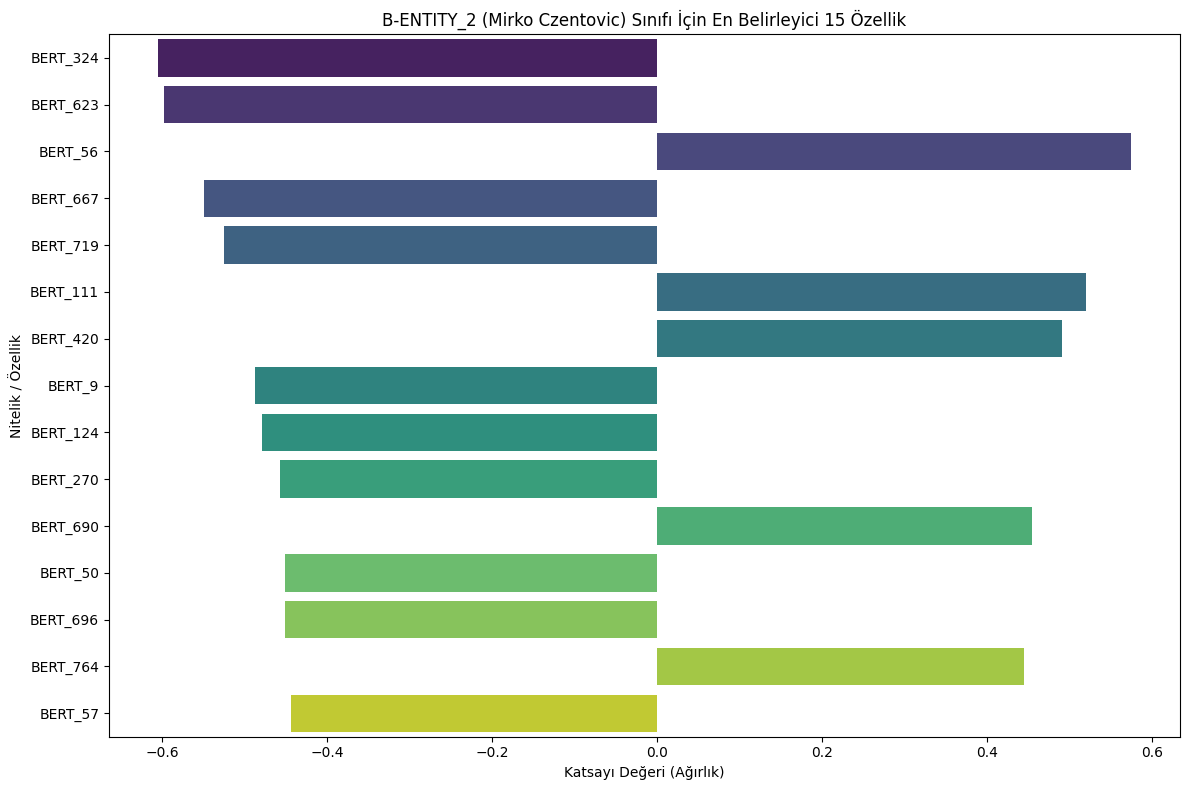

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Lojistik Regresyon katsayılarını inceleyelim
if 'B-ENTITY_2' in lr_model.classes_:
    class_idx = np.where(lr_model.classes_ == 'B-ENTITY_2')[0][0]
    coefs = lr_model.coef_[class_idx]
    
    # En yüksek ağırlığa sahip özellikleri bulalım (birleşik özellik uzayı için)
    bert_feature_names = [f"BERT_{d}" for d in range(768)]
    features_names = list(vectorizer.get_feature_names_out()) + bert_feature_names
    
    sorted_indices = np.argsort(np.abs(coefs))[::-1][:15]
    
    importance_list = []
    for idx in sorted_indices:
        importance_list.append((features_names[idx], coefs[idx]))
        
    df_importance = pd.DataFrame(importance_list, columns=['Özellik', 'Ağırlık (Katsayı)'])
    
    plt.figure(figsize=(12, 8))
    # FutureWarning'u çözmek için hue ve legend parametrelerini ekledik
    sns.barplot(data=df_importance, x='Ağırlık (Katsayı)', y='Özellik', hue='Özellik', palette='viridis', legend=False)
    plt.title('B-ENTITY_2 (Mirko Czentovic) Sınıfı İçin En Belirleyici 15 Özellik')
    plt.xlabel('Katsayı Değeri (Ağırlık)')
    plt.ylabel('Nitelik / Özellik')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300)
    plt.show()
else:
    print("B-ENTITY_2 sınıfı modelde bulunamadı.")


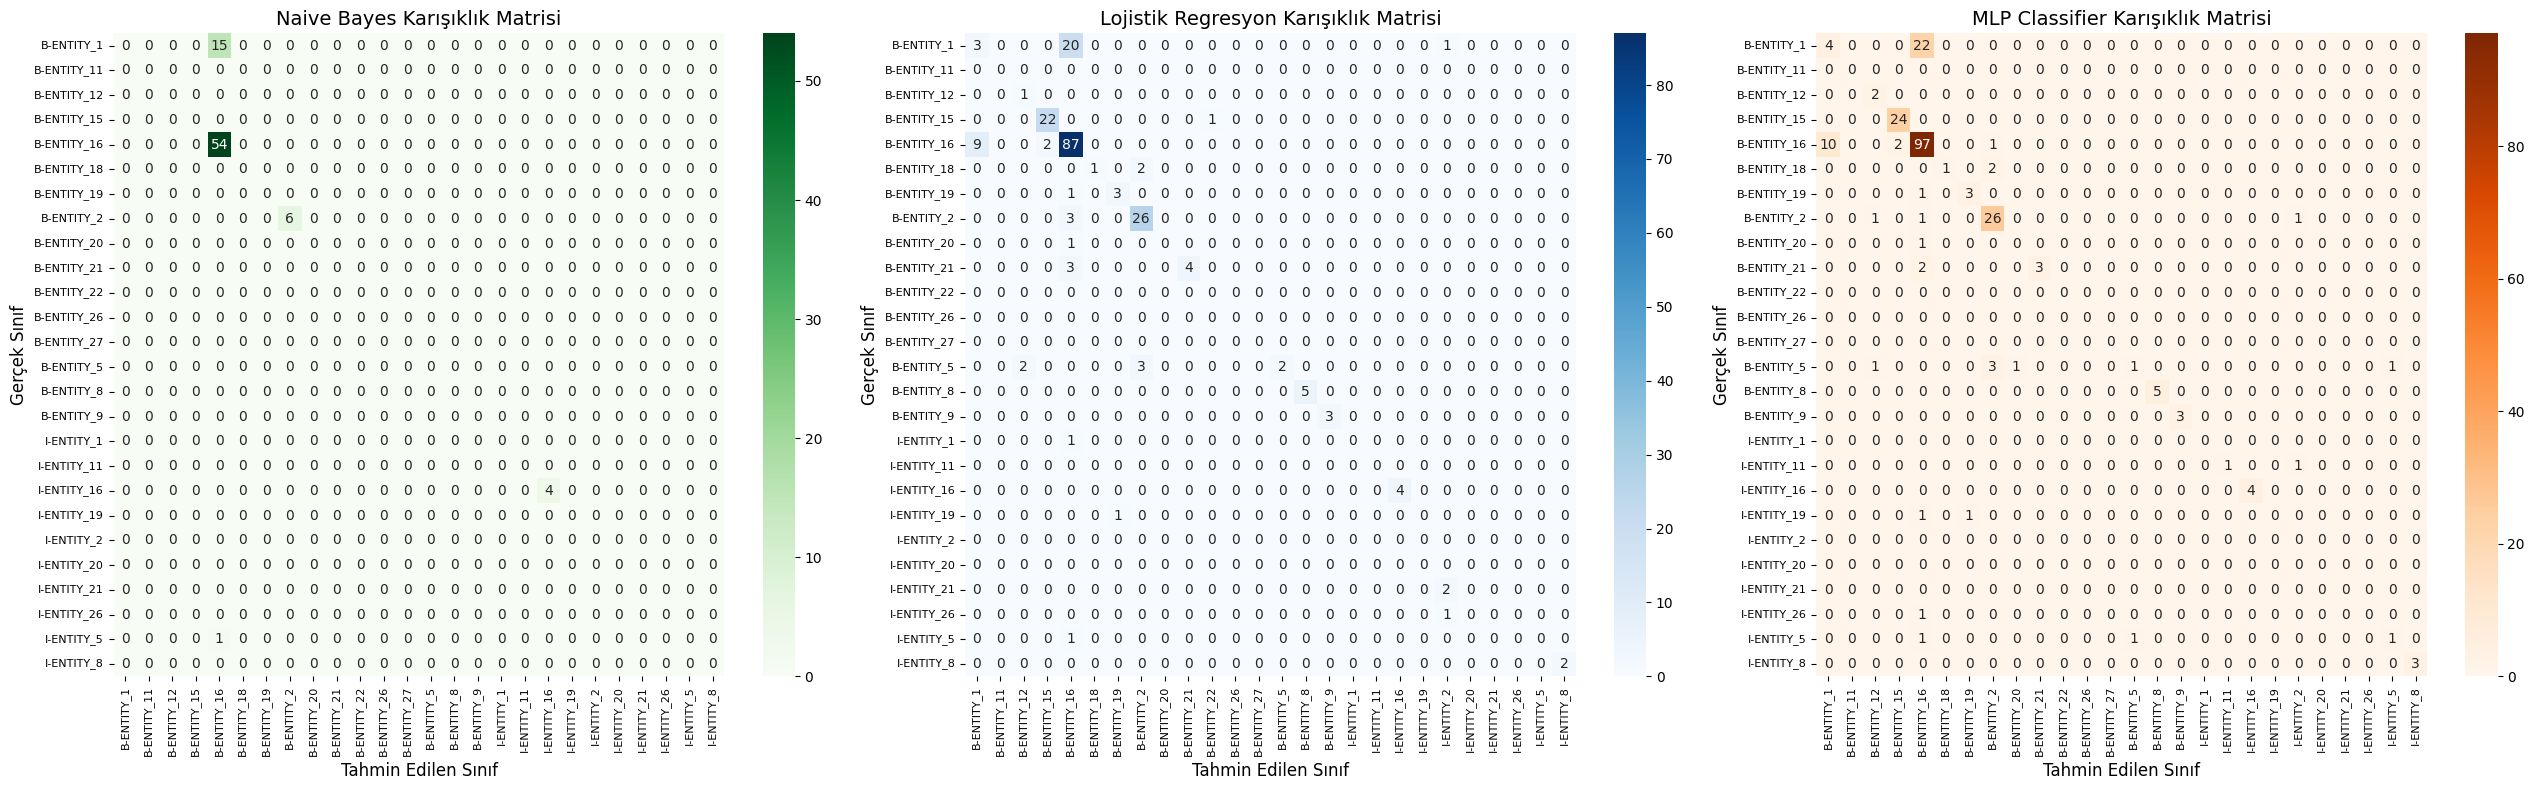

In [19]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(26, 8))

y_test_flat = np.array(y_test).flatten()
y_pred_nb_flat = np.array(y_pred_nb).flatten()
y_pred_lr_flat = np.array(y_pred_lr).flatten()
y_pred_mlp_flat = np.array(y_pred_mlp).flatten()

# Naive Bayes Matrisi
cm_nb = confusion_matrix(y_test_flat, y_pred_nb_flat, labels=entity_classes)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens', xticklabels=entity_classes, yticklabels=entity_classes, ax=axes[0])
axes[0].set_title('Naive Bayes Karışıklık Matrisi', fontsize=14)
axes[0].set_xlabel('Tahmin Edilen Sınıf', fontsize=12)
axes[0].set_ylabel('Gerçek Sınıf', fontsize=12)
axes[0].tick_params(axis='both', which='major', labelsize=8)

# Logistic Regression Matrisi
cm_lr = confusion_matrix(y_test_flat, y_pred_lr_flat, labels=entity_classes)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=entity_classes, yticklabels=entity_classes, ax=axes[1])
axes[1].set_title('Lojistik Regresyon Karışıklık Matrisi', fontsize=14)
axes[1].set_xlabel('Tahmin Edilen Sınıf', fontsize=12)
axes[1].set_ylabel('Gerçek Sınıf', fontsize=12)
axes[1].tick_params(axis='both', which='major', labelsize=8)

# MLP Classifier Matrisi
cm_mlp = confusion_matrix(y_test_flat, y_pred_mlp_flat, labels=entity_classes)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges', xticklabels=entity_classes, yticklabels=entity_classes, ax=axes[2])
axes[2].set_title('MLP Classifier Karışıklık Matrisi', fontsize=14)
axes[2].set_xlabel('Tahmin Edilen Sınıf', fontsize=12)
axes[2].set_ylabel('Gerçek Sınıf', fontsize=12)
axes[2].tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
plt.show()

                Model  Accuracy  Precision (Entity-Weighted)  Recall (Entity-Weighted)  F1-Score (Entity-Weighted)
          Naive Bayes  0.891816                     0.460929                  0.193353                    0.248210
   Lojistik Regresyon  0.916567                     0.581417                  0.492447                    0.507839
Yapay Sinir Ağı (MLP)  0.928942                     0.634609                  0.537764                    0.553432


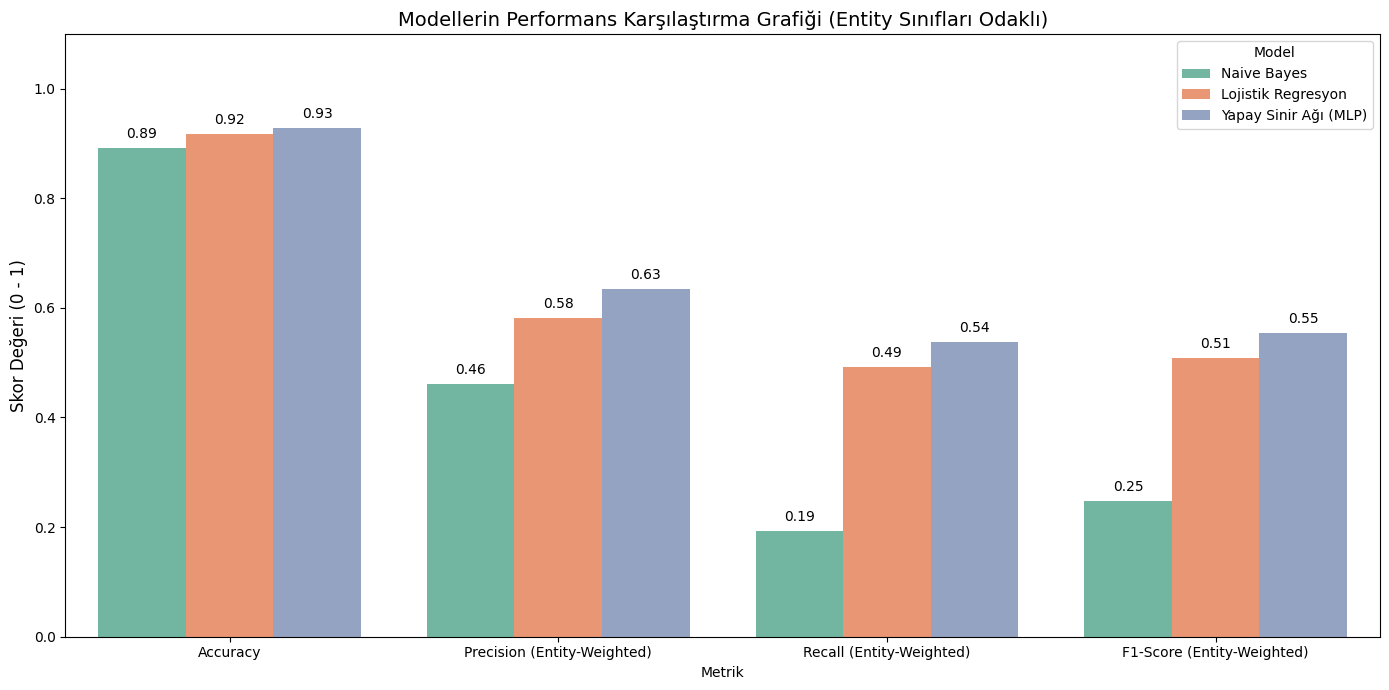

In [20]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# 0 sınıfı hariç tutulan metriklerin hesaplanması
metrics_data = {
    'Model': ['Naive Bayes', 'Lojistik Regresyon', 'Yapay Sinir Ağı (MLP)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb), 
        accuracy_score(y_test, y_pred_lr), 
        accuracy_score(y_test, y_pred_mlp)
    ],
    'Precision (Entity-Weighted)': [
        precision_score(y_test, y_pred_nb, labels=entity_classes, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_lr, labels=entity_classes, average='weighted', zero_division=0),
        precision_score(y_test, y_pred_mlp, labels=entity_classes, average='weighted', zero_division=0)
    ],
    'Recall (Entity-Weighted)': [
        recall_score(y_test, y_pred_nb, labels=entity_classes, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_lr, labels=entity_classes, average='weighted', zero_division=0),
        recall_score(y_test, y_pred_mlp, labels=entity_classes, average='weighted', zero_division=0)
    ],
    'F1-Score (Entity-Weighted)': [
        f1_score(y_test, y_pred_nb, labels=entity_classes, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_lr, labels=entity_classes, average='weighted', zero_division=0),
        f1_score(y_test, y_pred_mlp, labels=entity_classes, average='weighted', zero_division=0)
    ]
}

df_metrics = pd.DataFrame(metrics_data)
print(df_metrics.to_string(index=False))

# Grafik Çizimi
df_melted = df_metrics.melt(id_vars='Model', var_name='Metrik', value_name='Skor')
plt.figure(figsize=(14, 7))
sns.barplot(data=df_melted, x='Metrik', y='Skor', hue='Model', palette='Set2')
plt.title('Modellerin Performans Karşılaştırma Grafiği (Entity Sınıfları Odaklı)', fontsize=14)
plt.ylabel('Skor Değeri (0 - 1)', fontsize=12)
plt.ylim(0, 1.1)

# Grafik üzerine skorları yazdırma
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()

In [21]:
def predict_custom_sentence(sentence_text, model, vectorizer, is_combined=False):
    import re
    # Noktalama işaretlerinin önüne ve arkasına boşluk koyup split yapıyoruz
    sentence_text = re.sub(r'([.,!?;:\"\'()–])', r' \1 ', sentence_text)
    tokens = sentence_text.split()
    
    # Test verisi için boş etiketlerle yapı hazırlayalım
    sent = [(t, '0') for t in tokens]
    features = sent2features(sent)
    features_vec = vectorizer.transform(features)
    
    if is_combined:
        # BERT vektörünü çıkar
        inputs = tokenizer(tokens, is_split_into_words=True, return_tensors='pt', add_special_tokens=True).to(device)
        with torch.no_grad():
            outputs = bert_model(**inputs)
        last_hidden = outputs.last_hidden_state[0]
        word_ids = inputs.word_ids(batch_index=0)
        
        word_to_tokens = {}
        for token_idx, word_id in enumerate(word_ids):
            if word_id is not None:
                if word_id not in word_to_tokens:
                    word_to_tokens[word_id] = []
                word_to_tokens[word_id].append(token_idx)
                
        custom_embeddings = []
        for word_id in range(len(tokens)):
            token_indices = word_to_tokens.get(word_id, [])
            if token_indices:
                word_emb = last_hidden[token_indices].mean(dim=0).cpu().numpy()
            else:
                word_emb = np.zeros(768)
            custom_embeddings.append(word_emb)
            
        X_custom_bert = np.array(custom_embeddings)
        features_vec = hstack([features_vec, X_custom_bert])
        
    preds = model.predict(features_vec)
    
    print(f"{'Kelime':<18} | {'Tahmin Edilen Varlık Grubu'}")
    print("-" * 45)
    for token, pred in zip(tokens, preds):
        print(f"{token:<18} | {pred}")

sample_text = "Mirko Czentovic çok iyi bir satranç oyuncusuydu ve o rahip tarafından korundu ."

print("=== MULTINOMIAL NAIVE BAYES TAHMİNİ ===")
predict_custom_sentence(sample_text, nb_model, vectorizer, is_combined=False)

print("\n=== LOJİSTİK REGRESYON TAHMİNİ ===")
predict_custom_sentence(sample_text, lr_model, vectorizer, is_combined=True)

print("\n=== YAPAY SİNİR AĞI (MLP) TAHMİNİ ===")
predict_custom_sentence(sample_text, mlp_model, vectorizer, is_combined=True)


=== MULTINOMIAL NAIVE BAYES TAHMİNİ ===
Kelime             | Tahmin Edilen Varlık Grubu
---------------------------------------------
Mirko              | B-ENTITY_2
Czentovic          | B-ENTITY_2
çok                | 0
iyi                | 0
bir                | 0
satranç            | 0
oyuncusuydu        | 0
ve                 | 0
o                  | 0
rahip              | 0
tarafından         | 0
korundu            | 0
.                  | 0

=== LOJİSTİK REGRESYON TAHMİNİ ===
Kelime             | Tahmin Edilen Varlık Grubu
---------------------------------------------
Mirko              | I-ENTITY_2
Czentovic          | I-ENTITY_2
çok                | 0
iyi                | 0
bir                | 0
satranç            | 0
oyuncusuydu        | 0
ve                 | 0
o                  | 0
rahip              | 0
tarafından         | 0
korundu            | 0
.                  | 0

=== YAPAY SİNİR AĞI (MLP) TAHMİNİ ===
Kelime             | Tahmin Edilen Varlık Grubu
---------------